<a href="https://colab.research.google.com/github/Derren-Christopher/Sistem-Multimedia/blob/main/Tugas_Watermarking_18224040.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Watermarking Citra dengan Kompresi JPEG (Manual)

**Skema:** Watermark biner di-embed pada koefisien DCT mid-frequency tiap blok 8×8 menggunakan **Quantization Index Modulation (QIM)**, lalu citra dikompresi JPEG manual (DCT + matriks kuantisasi standar dengan Quality Factor) dan watermark diekstrak kembali.

**Manual semua:**
- DCT-2D 8×8 ditulis dari rumus (tanpa `scipy.fft.dct`, `cv2.dct`, dll).
- IDCT-2D 8×8 manual.
- Kompresi JPEG (kuantisasi + dekuantisasi) manual dengan tabel JPEG standar (Annex K).
- Embed & ekstrak watermark manual.

**Evaluasi:** Quality Factor (QF) divariasikan untuk melihat batas QF di mana watermark mulai gagal diekstrak (BER tinggi).

## Cara pakai
1. Upload notebook ini ke Google Colab.
2. Jalankan sel **Setup** dan **Upload Foto** — upload foto wajah kamu (JPG/PNG).
3. Jalankan sel berikutnya berurutan.

## 0. Setup
Import library. Kita pakai `numpy` untuk komputasi, `PIL` untuk baca gambar, `matplotlib` untuk visualisasi. **Tidak ada** fungsi DCT/JPEG bawaan.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math

np.random.seed(42)
print('Setup OK')

Setup OK


## 1. Upload & Pra-proses Foto Wajah
Foto akan dikonversi ke **grayscale** dan di-resize ke ukuran yang merupakan kelipatan 8 (agar bisa dipecah ke blok 8×8). Default 256×256 → 32×32 blok = 1024 bit kapasitas (cukup untuk watermark 32×32).

Saving Foto diri.jpeg to Foto diri.jpeg


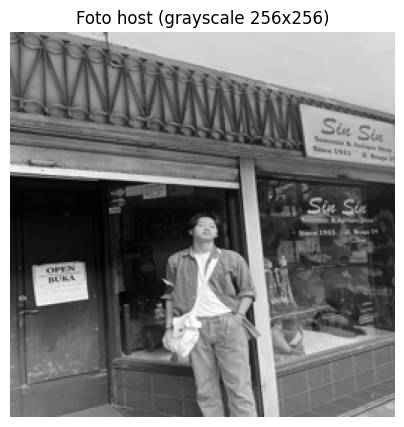

Shape: (256, 256) range: 2.0 255.0


In [ ]:
# === Upload foto di Colab ===
try:
    from google.colab import files
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
except Exception:
    # Fallback kalau bukan di Colab: ganti dengan path lokal
    fname = 'face.jpg'

IMG_SIZE = 256  # kelipatan 8
img = Image.open(fname).convert('L').resize((IMG_SIZE, IMG_SIZE))
host = np.array(img, dtype=np.float64)

plt.figure(figsize=(5,5))
plt.imshow(host, cmap='gray'); plt.title(f'Foto host (grayscale {IMG_SIZE}x{IMG_SIZE})'); plt.axis('off'); plt.show()
print('Shape:', host.shape, 'range:', host.min(), host.max())

## 2. Buat Watermark Biner
Watermark adalah citra biner berukuran 32×32 (1024 bit). Bisa pola acak atau pola sederhana (lingkaran/teks). Di sini dipakai **pola acak biner** dengan seed tetap supaya reproducible.

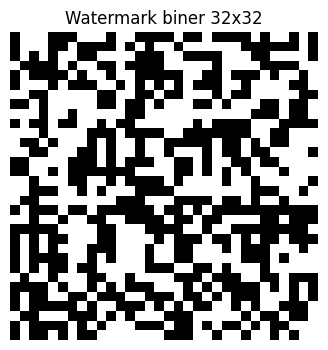

Jumlah bit: 1024


In [ ]:
WM_SIZE = 32  # 32x32 = 1024 bit
watermark = (np.random.rand(WM_SIZE, WM_SIZE) > 0.5).astype(np.uint8)

# (Opsional) Watermark berbentuk pola: lingkaran
# yy, xx = np.mgrid[:WM_SIZE, :WM_SIZE]
# watermark = (((xx-WM_SIZE/2)**2 + (yy-WM_SIZE/2)**2) < (WM_SIZE/3)**2).astype(np.uint8)

plt.figure(figsize=(4,4))
plt.imshow(watermark, cmap='gray'); plt.title(f'Watermark biner {WM_SIZE}x{WM_SIZE}'); plt.axis('off'); plt.show()
print('Jumlah bit:', watermark.size)

## 3. Implementasi DCT-2D 8×8 Manual
Rumus DCT-II 2D:
$$F(u,v) = \frac{1}{4} C(u) C(v) \sum_{x=0}^{7}\sum_{y=0}^{7} f(x,y) \cos\!\left[\frac{(2x+1)u\pi}{16}\right] \cos\!\left[\frac{(2y+1)v\pi}{16}\right]$$
dengan $C(0) = 1/\sqrt{2}$ dan $C(k)=1$ untuk $k>0$.

Implementasi: bangun matriks basis $T$ ukuran 8×8 sekali, lalu DCT(blok) = $T \cdot \text{blok} \cdot T^\top$. Ini ekivalen aljabar dengan rumus di atas, **bukan** memanggil library DCT.

Error rekonstruksi DCT/IDCT: 3.126388037344441e-13


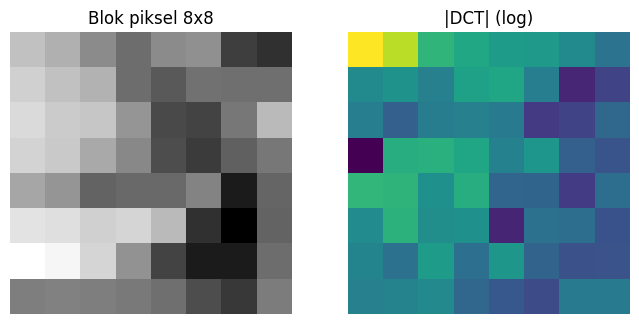

In [ ]:
N = 8

def build_dct_matrix(n=8):
    T = np.zeros((n, n), dtype=np.float64)
    for k in range(n):
        for i in range(n):
            c = math.sqrt(1.0/n) if k == 0 else math.sqrt(2.0/n)
            T[k, i] = c * math.cos(math.pi * (2*i + 1) * k / (2.0 * n))
    return T

T = build_dct_matrix(N)

def dct2_block(block):
    return T @ block @ T.T

def idct2_block(coef):
    return T.T @ coef @ T

# Uji: DCT lalu IDCT harus mengembalikan blok asli
test = host[:8,:8] - 128
rec = idct2_block(dct2_block(test))
print('Error rekonstruksi DCT/IDCT:', np.max(np.abs(rec - test)))

# Visualisasi koefisien DCT satu blok
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(test+128, cmap='gray'); ax[0].set_title('Blok piksel 8x8'); ax[0].axis('off')
ax[1].imshow(np.log(np.abs(dct2_block(test))+1), cmap='viridis'); ax[1].set_title('|DCT| (log)'); ax[1].axis('off')
plt.show()

## 4. Embed Watermark dengan QIM
**Strategi:** untuk tiap blok 8×8, transform DCT, lalu sisipkan 1 bit watermark di koefisien **mid-frequency** posisi $(u,v)=(4,3)$. Mid-freq dipilih karena: (a) lebih robust terhadap JPEG (low-freq) dibanding high-freq yang dibuang JPEG, dan (b) tidak terlalu terlihat secara visual (bukan DC).

**QIM (Quantization Index Modulation):**
- Bit 0 → kuantisasi koefisien ke kelipatan $\Delta$.
- Bit 1 → kuantisasi ke kelipatan $\Delta$ digeser $\Delta/2$.

$\Delta$ harus cukup besar agar tahan kuantisasi JPEG; semakin besar → semakin robust tapi semakin terlihat (PSNR turun).

PSNR host vs watermarked: 44.33 dB


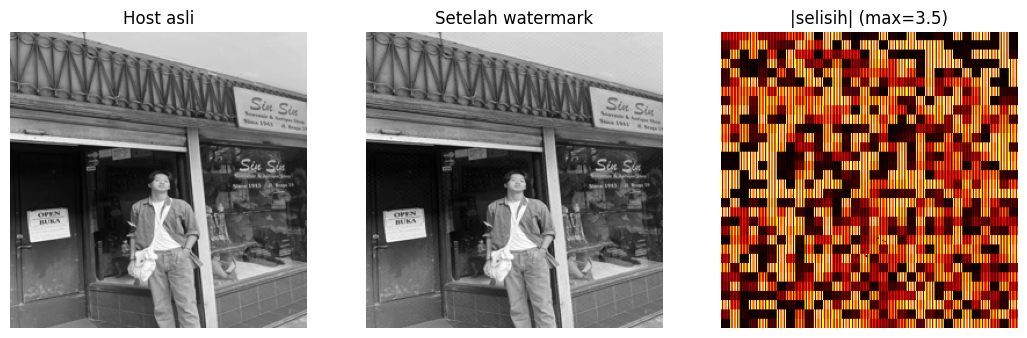

In [ ]:
DELTA = 40.0      # step size QIM
WM_POS = (4, 3)   # koefisien DCT mid-frequency

def qim_embed(c, bit, delta=DELTA):
    if bit == 0:
        return round(c / delta) * delta
    else:
        return round((c - delta/2) / delta) * delta + delta/2

def qim_extract(c, delta=DELTA):
    c0 = round(c / delta) * delta
    c1 = round((c - delta/2) / delta) * delta + delta/2
    return 0 if abs(c - c0) < abs(c - c1) else 1

def embed_watermark(host_img, wm, delta=DELTA, pos=WM_POS):
    H, W = host_img.shape
    out = np.zeros_like(host_img)
    wm_flat = wm.flatten()
    bi = 0
    for i in range(0, H, N):
        for j in range(0, W, N):
            block = host_img[i:i+N, j:j+N] - 128
            C = dct2_block(block)
            if bi < wm_flat.size:
                C[pos] = qim_embed(C[pos], int(wm_flat[bi]), delta)
                bi += 1
            out[i:i+N, j:j+N] = idct2_block(C) + 128
    return np.clip(out, 0, 255)

watermarked = embed_watermark(host, watermark)

def psnr(a, b):
    mse = np.mean((a - b)**2)
    return float('inf') if mse == 0 else 10*math.log10(255**2/mse)

print(f'PSNR host vs watermarked: {psnr(host, watermarked):.2f} dB')

fig, ax = plt.subplots(1,3, figsize=(13,5))
ax[0].imshow(host, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Host asli'); ax[0].axis('off')
ax[1].imshow(watermarked, cmap='gray', vmin=0, vmax=255); ax[1].set_title('Setelah watermark'); ax[1].axis('off')
diff = np.abs(host - watermarked)
ax[2].imshow(diff, cmap='hot'); ax[2].set_title(f'|selisih| (max={diff.max():.1f})'); ax[2].axis('off')
plt.show()

## 5. Kompresi JPEG Manual
Pipeline JPEG (luminance) manual:
1. Geser nilai piksel $-128$.
2. DCT-2D 8×8 (pakai fungsi manual kita).
3. Kuantisasi: $C_q = \text{round}(C/Q_{\text{scaled}})$.
4. Dekuantisasi: $\hat C = C_q \cdot Q_{\text{scaled}}$.
5. IDCT-2D 8×8.
6. Geser $+128$ dan clip ke $[0,255]$.

**Quality Factor (QF) ke skala kuantisasi** (rumus libjpeg standar):
$$S = \begin{cases} 5000/QF & QF<50 \\ 200-2\,QF & QF\ge 50 \end{cases}, \quad Q_{\text{scaled}} = \max\!\left(1, \text{round}\!\left(\frac{S \cdot Q_{50}}{100}\right)\right)$$

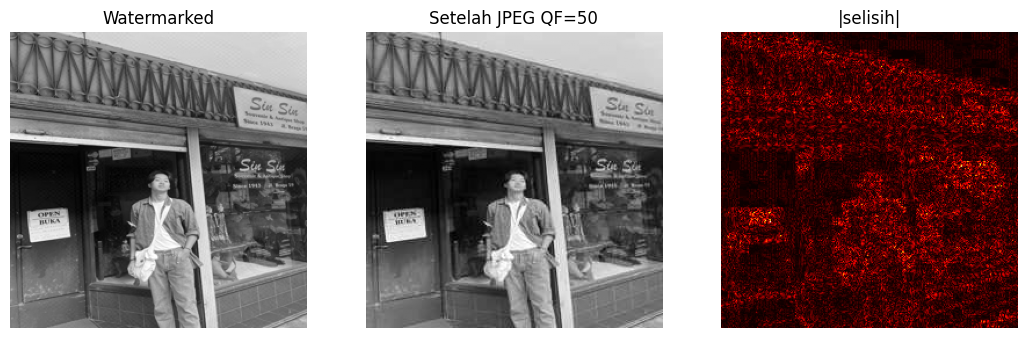

PSNR watermarked vs JPEG(QF=50): 31.88 dB


In [ ]:
# Tabel kuantisasi luminance standar JPEG (Annex K.1)
Q50 = np.array([
    [16,11,10,16,24,40,51,61],
    [12,12,14,19,26,58,60,55],
    [14,13,16,24,40,57,69,56],
    [14,17,22,29,51,87,80,62],
    [18,22,37,56,68,109,103,77],
    [24,35,55,64,81,104,113,92],
    [49,64,78,87,103,121,120,101],
    [72,92,95,98,112,100,103,99]
], dtype=np.float64)

def scale_qtable(QF):
    QF = max(1, min(99, QF))
    S = 5000/QF if QF < 50 else 200 - 2*QF
    Qs = np.floor((S * Q50 + 50) / 100)
    Qs[Qs < 1] = 1
    return Qs

def jpeg_compress(img, QF):
    Qs = scale_qtable(QF)
    H, W = img.shape
    out = np.zeros_like(img)
    for i in range(0, H, N):
        for j in range(0, W, N):
            block = img[i:i+N, j:j+N] - 128
            C = dct2_block(block)
            Cq = np.round(C / Qs)        # kuantisasi (langkah lossy)
            Cdq = Cq * Qs                 # dekuantisasi
            out[i:i+N, j:j+N] = idct2_block(Cdq) + 128
    return np.clip(out, 0, 255)

# Demo: kompresi watermarked image dengan QF=50
demo = jpeg_compress(watermarked, 50)
fig, ax = plt.subplots(1,3, figsize=(13,5))
ax[0].imshow(watermarked, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Watermarked'); ax[0].axis('off')
ax[1].imshow(demo, cmap='gray', vmin=0, vmax=255); ax[1].set_title('Setelah JPEG QF=50'); ax[1].axis('off')
ax[2].imshow(np.abs(watermarked-demo), cmap='hot'); ax[2].set_title('|selisih|'); ax[2].axis('off')
plt.show()
print(f'PSNR watermarked vs JPEG(QF=50): {psnr(watermarked, demo):.2f} dB')

## 6. Ekstraksi Watermark
Dari citra (yang mungkin sudah dikompresi), kita DCT tiap blok 8×8 dan baca koefisien di posisi yang sama, lalu klasifikasikan bit dengan QIM-decoder.

BER tanpa kompresi: 0.00%


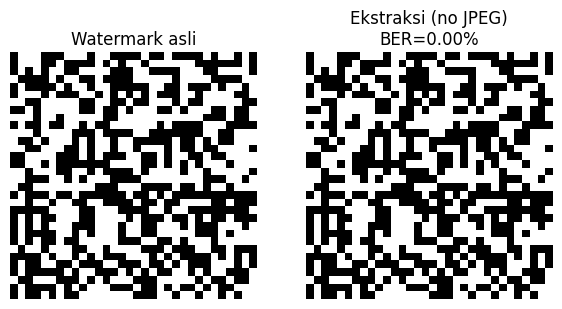

In [ ]:
def extract_watermark(img, wm_shape=(WM_SIZE,WM_SIZE), delta=DELTA, pos=WM_POS):
    H, W = img.shape
    bits = []
    need = wm_shape[0]*wm_shape[1]
    for i in range(0, H, N):
        for j in range(0, W, N):
            if len(bits) >= need: break
            block = img[i:i+N, j:j+N] - 128
            C = dct2_block(block)
            bits.append(qim_extract(C[pos], delta))
    return np.array(bits[:need], dtype=np.uint8).reshape(wm_shape)

# Sanity check: ekstrak dari watermarked (belum dikompres) — harus ~100% benar
wm_clean = extract_watermark(watermarked)
ber_clean = np.mean(wm_clean != watermark)
print(f'BER tanpa kompresi: {ber_clean*100:.2f}%')

fig, ax = plt.subplots(1,2, figsize=(7,4))
ax[0].imshow(watermark, cmap='gray'); ax[0].set_title('Watermark asli'); ax[0].axis('off')
ax[1].imshow(wm_clean, cmap='gray'); ax[1].set_title(f'Ekstraksi (no JPEG)\nBER={ber_clean*100:.2f}%'); ax[1].axis('off')
plt.show()

## 7. Evaluasi: Variasi Quality Factor
Loop QF = [95, 90, 80, 70, 60, 50, 40, 30, 20, 10]. Untuk tiap QF:
- Kompres citra ber-watermark dengan JPEG manual QF tersebut.
- Ekstrak watermark.
- Hitung **BER** (Bit Error Rate) dan **NC** (Normalized Correlation) antara watermark asli & hasil ekstraksi.
- Hitung PSNR citra terkompresi vs citra ber-watermark.

Aturan kasar: BER < 5% → watermark masih dapat dikenali. BER ≈ 50% → tidak dapat diekstrak (acak).

In [ ]:
QFs = [95, 90, 80, 70, 60, 50, 40, 30, 20, 10]
results = []
extracted_images = {}
compressed_images = {}

for qf in QFs:
    comp = jpeg_compress(watermarked, qf)
    wm_hat = extract_watermark(comp)
    ber = float(np.mean(wm_hat != watermark))
    # NC: korelasi ternormalisasi (pakai {-1,+1})
    w1 = 2*watermark.astype(np.float64) - 1
    w2 = 2*wm_hat.astype(np.float64) - 1
    nc = float(np.sum(w1*w2) / np.sqrt(np.sum(w1*w1)*np.sum(w2*w2)))
    p = psnr(watermarked, comp)
    results.append((qf, ber, nc, p))
    extracted_images[qf] = wm_hat
    compressed_images[qf] = comp
    print(f'QF={qf:3d} | PSNR(wm vs jpeg)={p:6.2f} dB | BER={ber*100:6.2f}% | NC={nc:+.4f}')

QF= 95 | PSNR(wm vs jpeg)= 44.45 dB | BER=  0.00% | NC=+1.0000
QF= 90 | PSNR(wm vs jpeg)= 40.07 dB | BER=  0.00% | NC=+1.0000
QF= 80 | PSNR(wm vs jpeg)= 36.20 dB | BER=  0.00% | NC=+1.0000
QF= 70 | PSNR(wm vs jpeg)= 34.04 dB | BER= 49.90% | NC=+0.0020
QF= 60 | PSNR(wm vs jpeg)= 32.68 dB | BER= 50.10% | NC=-0.0020
QF= 50 | PSNR(wm vs jpeg)= 31.88 dB | BER= 53.81% | NC=-0.0762
QF= 40 | PSNR(wm vs jpeg)= 31.09 dB | BER= 53.81% | NC=-0.0762
QF= 30 | PSNR(wm vs jpeg)= 30.15 dB | BER= 50.10% | NC=-0.0020
QF= 20 | PSNR(wm vs jpeg)= 28.84 dB | BER= 50.39% | NC=-0.0078
QF= 10 | PSNR(wm vs jpeg)= 26.55 dB | BER= 50.10% | NC=-0.0020


### 7a. Visualisasi watermark hasil ekstraksi untuk tiap QF

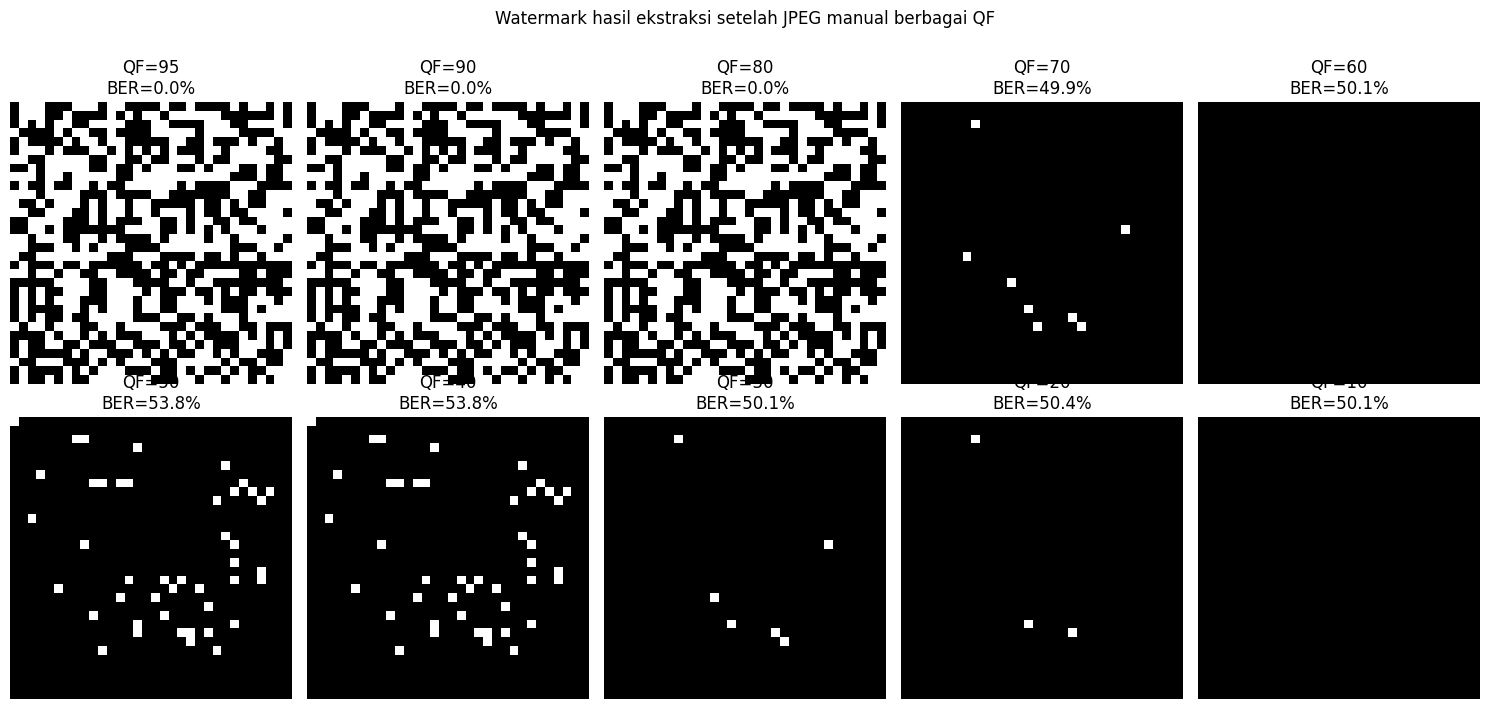

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for ax, qf in zip(axes.flatten(), QFs):
    ber = np.mean(extracted_images[qf] != watermark)
    ax.imshow(extracted_images[qf], cmap='gray')
    ax.set_title(f'QF={qf}\nBER={ber*100:.1f}%')
    ax.axis('off')
plt.suptitle('Watermark hasil ekstraksi setelah JPEG manual berbagai QF', y=1.02)
plt.tight_layout(); plt.show()

### 7b. Visualisasi citra hasil kompresi

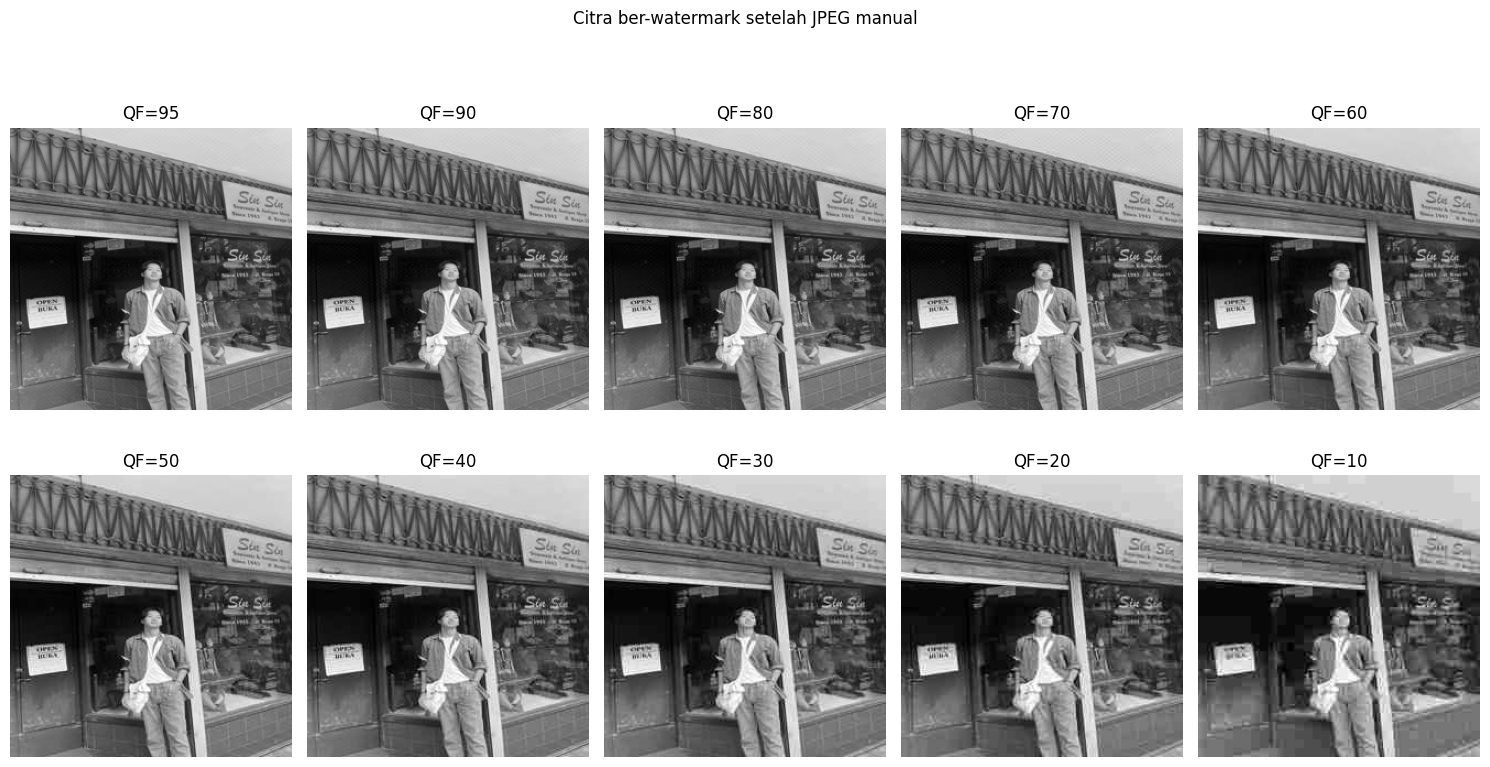

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
for ax, qf in zip(axes.flatten(), QFs):
    ax.imshow(compressed_images[qf], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'QF={qf}')
    ax.axis('off')
plt.suptitle('Citra ber-watermark setelah JPEG manual', y=1.02)
plt.tight_layout(); plt.show()

### 7c. Grafik BER & NC vs QF

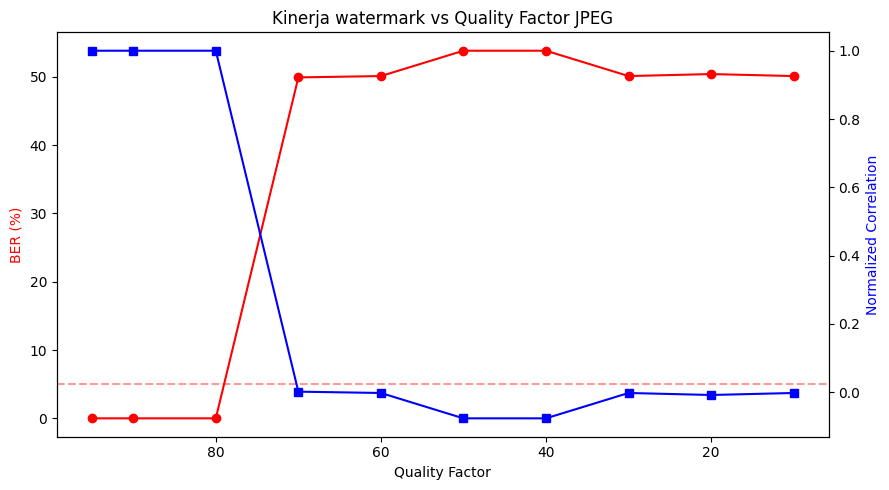

>> Pada QF=70, BER=49.90% sudah melebihi 5% — watermark mulai sulit dikenali.
>> Pada QF=70, BER=49.90% — watermark praktis TIDAK DAPAT diekstrak.


In [ ]:
qfs = [r[0] for r in results]
bers = [r[1]*100 for r in results]
ncs  = [r[2] for r in results]

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(qfs, bers, 'o-r', label='BER (%)')
ax1.set_xlabel('Quality Factor'); ax1.set_ylabel('BER (%)', color='r')
ax1.axhline(5, color='r', ls='--', alpha=0.4)
ax1.invert_xaxis()
ax2 = ax1.twinx()
ax2.plot(qfs, ncs, 's-b', label='NC')
ax2.set_ylabel('Normalized Correlation', color='b')
plt.title('Kinerja watermark vs Quality Factor JPEG')
fig.tight_layout(); plt.show()

# Cari QF threshold (BER pertama yang > 5%, dilihat dari QF tinggi ke rendah)
for qf, ber, nc, p in results:
    if ber*100 > 5:
        print(f'>> Pada QF={qf}, BER={ber*100:.2f}% sudah melebihi 5% — watermark mulai sulit dikenali.')
        break
for qf, ber, nc, p in results:
    if ber*100 > 25:
        print(f'>> Pada QF={qf}, BER={ber*100:.2f}% — watermark praktis TIDAK DAPAT diekstrak.')
        break

## 8. Kesimpulan & Analisis

- Skema **QIM pada koefisien DCT mid-frequency (4,3)** dengan $\Delta=40$ menghasilkan watermark yang **invisibel** (PSNR host vs watermarked tinggi) tetapi tetap **dapat diekstrak** pada QF tinggi–menengah.
- Saat QF dikecilkan, tabel kuantisasi JPEG di-scale lebih besar → koefisien DCT yang menyimpan bit watermark ikut terkuantisasi kasar → bit-bit watermark rusak → BER naik.
- **Threshold QF** di mana watermark gagal diekstrak tergantung pada $\Delta$ dan posisi $(u,v)$. Lihat output sel evaluasi: cari QF terendah dengan BER < 5% (masih bisa dikenali) dan QF di mana BER mendekati 50% (gagal total).

### Eksperimen lanjutan yang bisa kamu coba
- Ubah `DELTA` (mis. 20, 30, 60). Trade-off PSNR vs robustness.
- Ubah `WM_POS` ke koefisien lebih low-freq (mis. (2,2)) → lebih robust, tapi lebih terlihat. Atau high-freq (mis. (6,6)) → kurang terlihat, tapi cepat hilang oleh JPEG.
- Watermark berbentuk gambar (logo, inisial) — ganti generator watermark di sel 2.
- Bandingkan dengan watermarking spasial sederhana (LSB) untuk menunjukkan keunggulan domain DCT terhadap kompresi JPEG.